# Assignment 1 Lab Question

### Q1. Generate synthetic datasets for clustering.
#### a) Use make_blobs( ) to create a dataset with 3 clusters.
#####        Note: make_blobs( ) is a function in scikit-learn used to generate synthetic datasets with clusters.
#### b) Visualize the dataset using a scatter plot.
#### c) Change the number of clusters and observe the results.

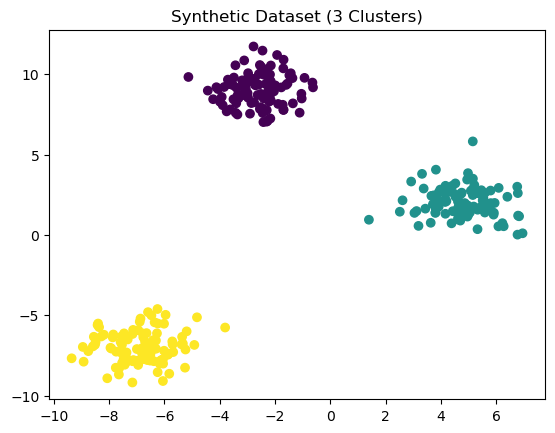

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=3, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Synthetic Dataset (3 Clusters)")
plt.show()

### Q2. Determine the optimal number of clusters using Elbow Method
#### a) Generate a dataset using make_blobs( ).
#### b) Apply K-Means for different values of k (k=1 to 9).
#### c) Calculate inertia (sum of squared distances).
#### d) Plot the Elbow graph.

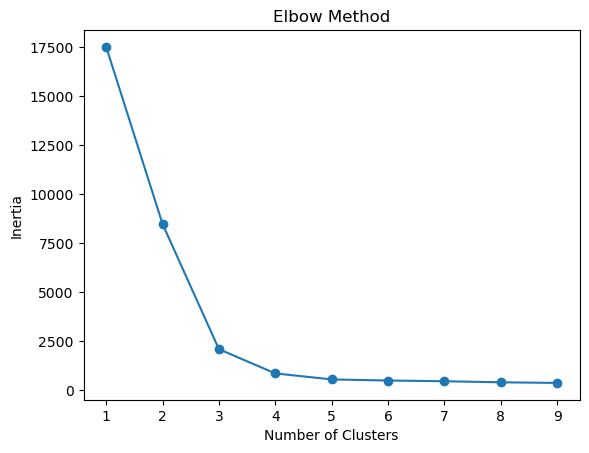

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=5, random_state=42)

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Q3. Perform clustering using K-Means on a synthetic dataset.
#### a) Generate a dataset using make_blobs( ).
#### b) Apply the K-Means algorithm.
#### c) Change the number of clusters from 2 to 5.
#### d) Plot clusters and centroids.
#### e) Observe how cluster formation changes.

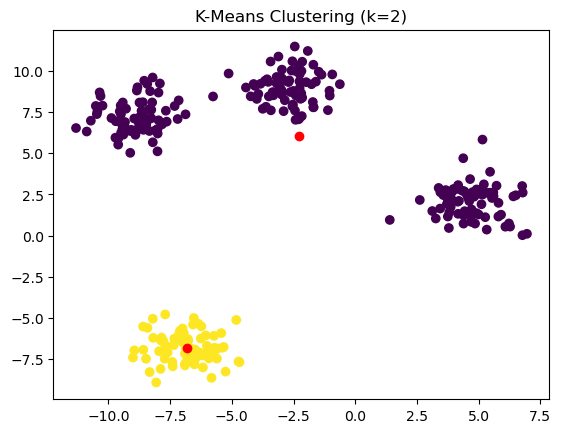

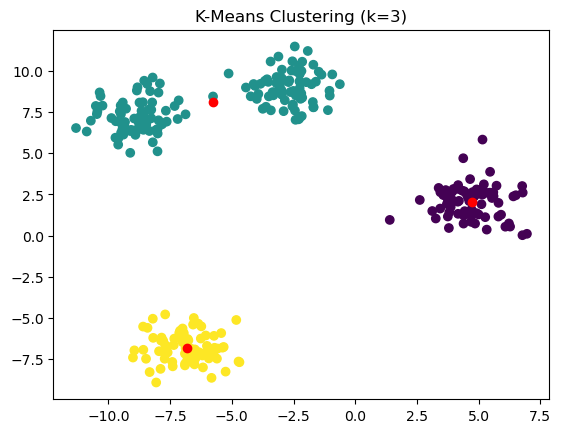

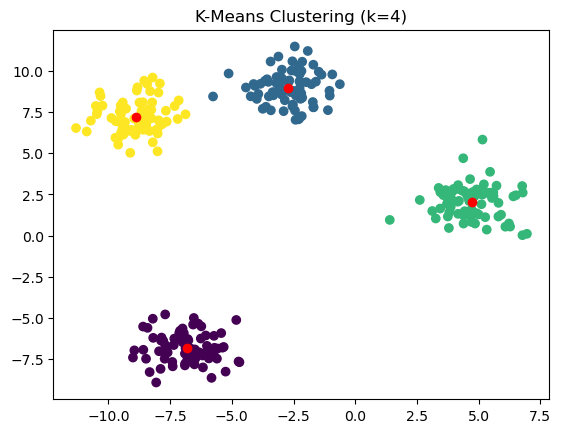

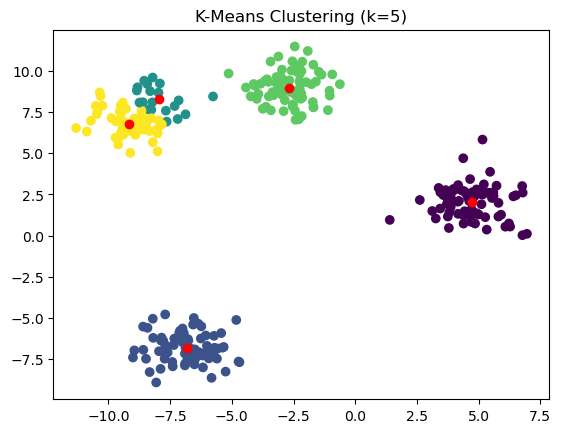

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=4, random_state=42)

for k in range(2,6):
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(X)

    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.scatter(kmeans.cluster_centers_[:,0],
                kmeans.cluster_centers_[:,1],
                color='red')
    plt.title(f"K-Means Clustering (k={k})")
    plt.show()

### Q4. Perform clustering using Hierarchical Clustering on a synthetic dataset.
#### a) Generate a dataset using make_blobs( ).
#### b) Apply Agglomerative Clustering.
#### c) Plot a dendrogram.
#### d) Compare results with K-Means clustering.

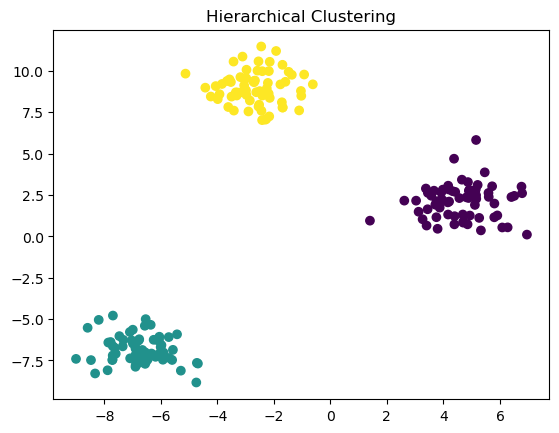

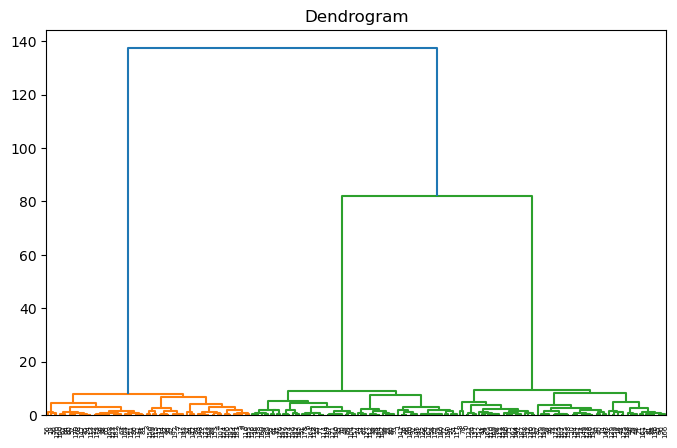

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

X, y = make_blobs(n_samples=200, centers=3, random_state=42)

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Hierarchical Clustering")
plt.show()

Z = linkage(X, method='ward')

plt.figure(figsize=(8,5))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()

### Q5. Find patterns using association rules.
#### a) Create a small transaction dataset.
#### b) Apply the Apriori algorithm.
#### c) Calculate support and confidence.
#### d) Generate association rules.

In [7]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

data = pd.DataFrame({
'Milk':[1,1,0,1,0],
'Bread':[1,1,1,0,1],
'Butter':[0,1,1,1,0],
'Eggs':[1,0,1,1,1]
})

freq_items = apriori(data, min_support=0.4, use_colnames=True)

rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)

print(freq_items)
print(rules)

   support                    itemsets
0      0.6           frozenset({Milk})
1      0.8          frozenset({Bread})
2      0.6         frozenset({Butter})
3      0.8           frozenset({Eggs})
4      0.4    frozenset({Milk, Bread})
5      0.4   frozenset({Milk, Butter})
6      0.4     frozenset({Milk, Eggs})
7      0.4  frozenset({Butter, Bread})
8      0.6    frozenset({Eggs, Bread})
9      0.4   frozenset({Butter, Eggs})
           antecedents          consequents  antecedent support  \
0    frozenset({Milk})   frozenset({Bread})                 0.6   
1    frozenset({Milk})  frozenset({Butter})                 0.6   
2  frozenset({Butter})    frozenset({Milk})                 0.6   
3    frozenset({Milk})    frozenset({Eggs})                 0.6   
4  frozenset({Butter})   frozenset({Bread})                 0.6   
5    frozenset({Eggs})   frozenset({Bread})                 0.8   
6   frozenset({Bread})    frozenset({Eggs})                 0.8   
7  frozenset({Butter})    frozenset

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


### Q6. Implement Artificial Neuron Calculation.
#### a) Take input values x1, x2, x3.
#### b) Assign weights w1, w2, w3.
#### c) Compute neuron output using: y=f(w1x1+w2x2+w3x3+b)
#### d) Implement it using each of the following activation function: step function, Sigmoid function, Tanh function, ReLU function

In [8]:
import numpy as np

x = np.array([1,2,3])
w = np.array([0.5,0.3,0.2])
b = 0.1

z = np.dot(w,x) + b

step = 1 if z >= 0 else 0

sigmoid = 1/(1+np.exp(-z))

tanh = np.tanh(z)

relu = max(0,z)

print("Step:",step)
print("Sigmoid:",sigmoid)
print("Tanh:",tanh)
print("ReLU:",relu)

Step: 1
Sigmoid: 0.8581489350995123
Tanh: 0.9468060128462683
ReLU: 1.8000000000000003


### Q7. Train a perceptron classifier on a synthetic dataset.
#### a) Generate a dataset using make_classification( ).
#### b) Train a perceptron classifier.
#### c) Plot the decision boundary.
#### d) Identify misclassified points and compute accuracy.

Accuracy: 0.515


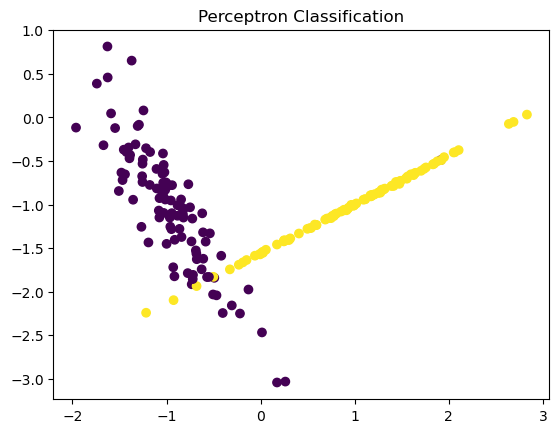

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron

X, y = make_classification(n_samples=200,n_features=2,n_redundant=0,n_clusters_per_class=1)

model = Perceptron()
model.fit(X,y)

accuracy = model.score(X,y)
print("Accuracy:",accuracy)

plt.scatter(X[:,0],X[:,1],c=y)
plt.title("Perceptron Classification")
plt.show()

### Q8. Implement a neural network classifier using MLPClassifier
#### a) Create a dataset.
#### b) Train a neural network classifier.
#### c) Change number of hidden layers.
#### d) Compare model accuracy.

In [10]:
from sklearn.datasets import make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X,y = make_classification(n_samples=500)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000)

model.fit(X_train,y_train)

print("Accuracy:",model.score(X_test,y_test))

Accuracy: 0.92


### Q9. Design a neural network with one hidden layer and train it using backpropagation to classify two classes.
#### a) Create or load a small dataset containing two classes and split it into training and testing sets.
#### b) Design the neural network architecture with an input layer, one hidden layer, and an output layer. Initialize weights and biases.
#### c) Perform forward propagation to compute the predicted output using an activation function.
#### d) Apply the backpropagation algorithm to update weights and train the network, then evaluate the classification accuracy.

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X,y = make_classification(n_samples=300)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000)

model.fit(X_train,y_train)

print("Accuracy:",model.score(X_test,y_test))

Accuracy: 0.85


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Q10. Complete ML Workflow.
#### a) Generate dataset.
#### b) Perform clustering to identify patterns.
#### c) Train perceptron classifier.
#### d) Train neural network classifier.
#### e) Compare results.

In [13]:
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

X,y = make_classification(n_samples=300)

kmeans = KMeans(n_clusters=3, n_init=10)
clusters = kmeans.fit_predict(X)

p = Perceptron()
p.fit(X,y)
print("Perceptron Accuracy:",p.score(X,y))

nn = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000)
nn.fit(X,y)
print("Neural Network Accuracy:",nn.score(X,y))

Perceptron Accuracy: 0.87
Neural Network Accuracy: 1.0
